Ejercicio 1

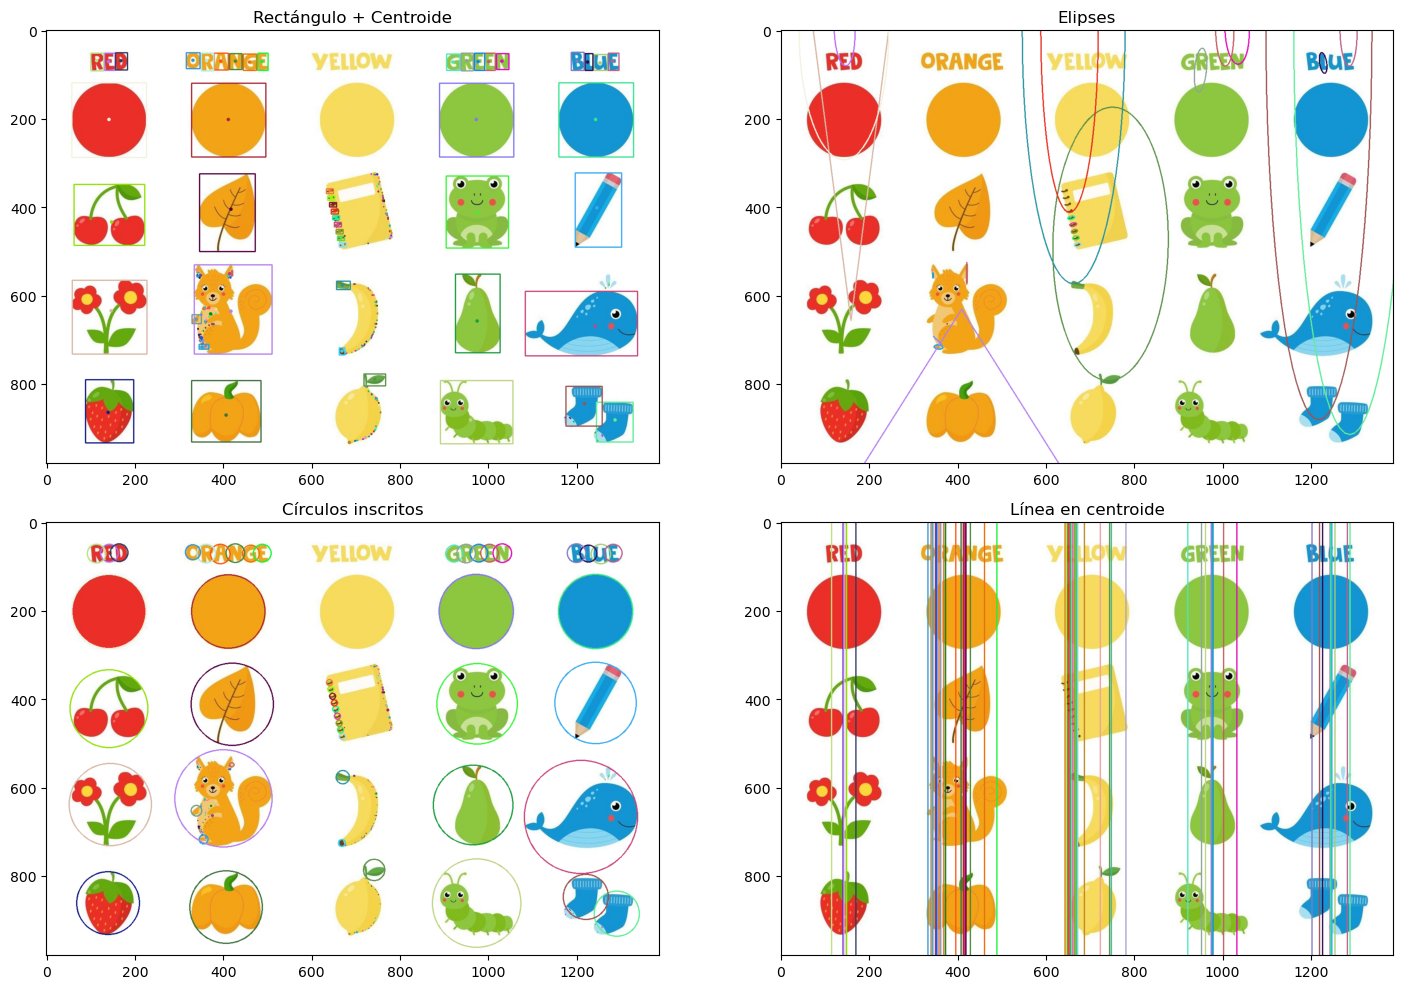

Contorno 1: Área = 0.50, Perímetro = 8.24
Contorno 2: Área = 0.00, Perímetro = 2.00
Contorno 3: Área = 0.00, Perímetro = 0.00
Contorno 4: Área = 0.00, Perímetro = 4.00
Contorno 5: Área = 0.00, Perímetro = 2.00
Contorno 6: Área = 0.50, Perímetro = 3.41
Contorno 7: Área = 0.00, Perímetro = 0.00
Contorno 8: Área = 0.00, Perímetro = 0.00
Contorno 9: Área = 0.00, Perímetro = 0.00
Contorno 10: Área = 0.00, Perímetro = 0.00
Contorno 11: Área = 0.00, Perímetro = 2.83
Contorno 12: Área = 0.00, Perímetro = 0.00
Contorno 13: Área = 0.00, Perímetro = 0.00
Contorno 14: Área = 0.00, Perímetro = 2.00
Contorno 15: Área = 0.00, Perímetro = 2.83
Contorno 16: Área = 0.00, Perímetro = 0.00
Contorno 17: Área = 0.00, Perímetro = 0.00
Contorno 18: Área = 0.00, Perímetro = 2.00
Contorno 19: Área = 0.00, Perímetro = 0.00
Contorno 20: Área = 0.00, Perímetro = 0.00
Contorno 21: Área = 0.00, Perímetro = 2.00
Contorno 22: Área = 0.00, Perímetro = 0.00
Contorno 23: Área = 0.00, Perímetro = 0.00
Contorno 24: Área = 

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('colores.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
_, binaria = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_rect = imagen_rgb.copy()
img_elipse = imagen_rgb.copy()
img_circulo = imagen_rgb.copy()
img_linea = imagen_rgb.copy()
areas = []
perimetros = []

for i, cnt in enumerate(contornos):
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)
    areas.append(area)
    perimetros.append(perimetro)
    color = tuple(np.random.randint(0, 255, 3).tolist())  
    cv2.circle(img_rect, (cx, cy), 4, color, -1)
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_rect, (x, y), (x + w, y + h), color, 2)
    if len(cnt) >= 5:
        try:
            ellipse = cv2.fitEllipse(cnt)
            if ellipse[1][0] > 0 and ellipse[1][1] > 0:  
                cv2.ellipse(img_elipse, ellipse, color, 2)
        except:
            continue  
    (x_circ, y_circ), radius = cv2.minEnclosingCircle(cnt)
    center = (int(x_circ), int(y_circ))
    radius = int(radius)
    cv2.circle(img_circulo, center, radius, color, 2)

    cv2.line(img_linea, (cx, 0), (cx, img_linea.shape[0]), color, 2)

plt.figure(figsize=(15, 10))
plt.subplot(221), plt.imshow(img_rect)
plt.title("Rectángulo + Centroide")
plt.subplot(222), plt.imshow(img_elipse)
plt.title("Elipses")
plt.subplot(223), plt.imshow(img_circulo)
plt.title("Círculos inscritos")
plt.subplot(224), plt.imshow(img_linea)
plt.title("Línea en centroide")
plt.tight_layout()
plt.show()

for i, (a, p) in enumerate(zip(areas, perimetros), 1):
    print(f"Contorno {i}: Área = {a:.2f}, Perímetro = {p:.2f}")


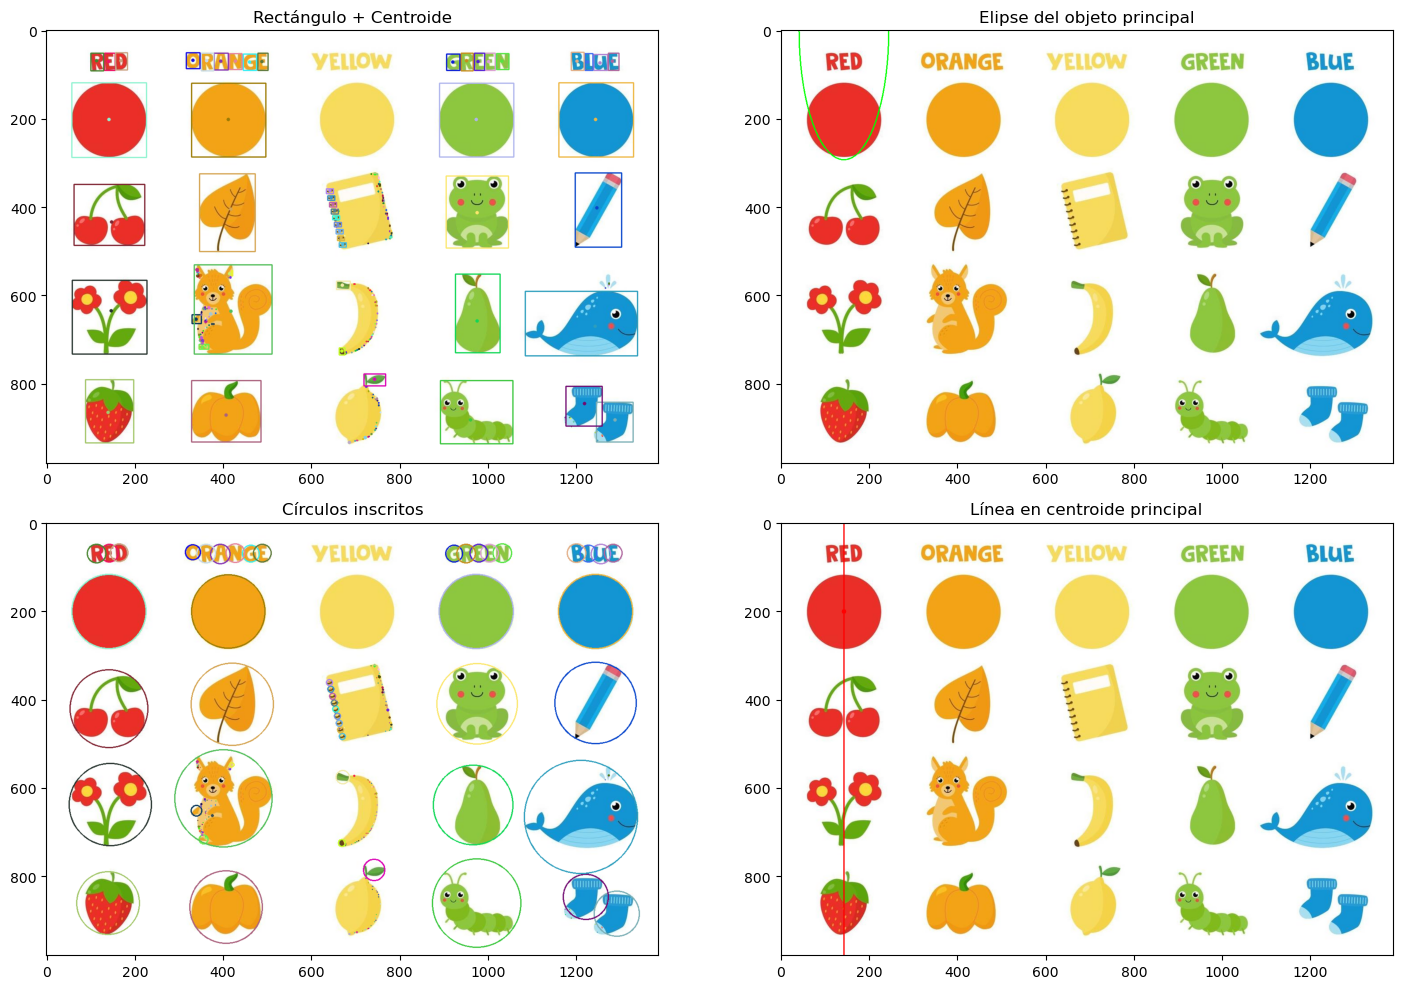

Contorno 1: Área = 0.50, Perímetro = 8.24
Contorno 2: Área = 0.00, Perímetro = 2.00
Contorno 3: Área = 0.00, Perímetro = 0.00
Contorno 4: Área = 0.00, Perímetro = 4.00
Contorno 5: Área = 0.00, Perímetro = 2.00
Contorno 6: Área = 0.50, Perímetro = 3.41
Contorno 7: Área = 0.00, Perímetro = 0.00
Contorno 8: Área = 0.00, Perímetro = 0.00
Contorno 9: Área = 0.00, Perímetro = 0.00
Contorno 10: Área = 0.00, Perímetro = 0.00
Contorno 11: Área = 0.00, Perímetro = 2.83
Contorno 12: Área = 0.00, Perímetro = 0.00
Contorno 13: Área = 0.00, Perímetro = 0.00
Contorno 14: Área = 0.00, Perímetro = 2.00
Contorno 15: Área = 0.00, Perímetro = 2.83
Contorno 16: Área = 0.00, Perímetro = 0.00
Contorno 17: Área = 0.00, Perímetro = 0.00
Contorno 18: Área = 0.00, Perímetro = 2.00
Contorno 19: Área = 0.00, Perímetro = 0.00
Contorno 20: Área = 0.00, Perímetro = 0.00
Contorno 21: Área = 0.00, Perímetro = 2.00
Contorno 22: Área = 0.00, Perímetro = 0.00
Contorno 23: Área = 0.00, Perímetro = 0.00
Contorno 24: Área = 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('colores.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
_, binaria = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_rect = imagen_rgb.copy()
img_elipse = imagen_rgb.copy()
img_circulo = imagen_rgb.copy()
img_linea = imagen_rgb.copy()

areas = []
perimetros = []

max_area = 0
contorno_principal = None
centro_principal = (0, 0)

for i, cnt in enumerate(contornos):
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)
    areas.append(area)
    perimetros.append(perimetro)
    color = tuple(np.random.randint(0, 255, 3).tolist())

    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_rect, (x, y), (x + w, y + h), color, 2)
    cv2.circle(img_rect, (cx, cy), 4, color, -1)

    if area > max_area:
        max_area = area
        contorno_principal = cnt
        centro_principal = (cx, cy)

    (x_circ, y_circ), radius = cv2.minEnclosingCircle(cnt)
    center = (int(x_circ), int(y_circ))
    radius = int(radius)
    cv2.circle(img_circulo, center, radius, color, 2)

if contorno_principal is not None and len(contorno_principal) >= 5:
    try:
        ellipse = cv2.fitEllipse(contorno_principal)
        if ellipse[1][0] > 0 and ellipse[1][1] > 0:
            cv2.ellipse(img_elipse, ellipse, (0, 255, 0), 2)
    except:
        pass

cx, cy = centro_principal
cv2.line(img_linea, (cx, 0), (cx, img_linea.shape[0]), (255, 0, 0), 2)
cv2.circle(img_linea, (cx, cy), 5, (255, 0, 0), -1)

plt.figure(figsize=(15, 10))
plt.subplot(221), plt.imshow(img_rect)
plt.title("Rectángulo + Centroide")
plt.subplot(222), plt.imshow(img_elipse)
plt.title("Elipse del objeto principal")
plt.subplot(223), plt.imshow(img_circulo)
plt.title("Círculos inscritos")
plt.subplot(224), plt.imshow(img_linea)
plt.title("Línea en centroide principal")
plt.tight_layout()
plt.show()

for i, (a, p) in enumerate(zip(areas, perimetros), 1):
    print(f"Contorno {i}: Área = {a:.2f}, Perímetro = {p:.2f}")


Ejercicio 2

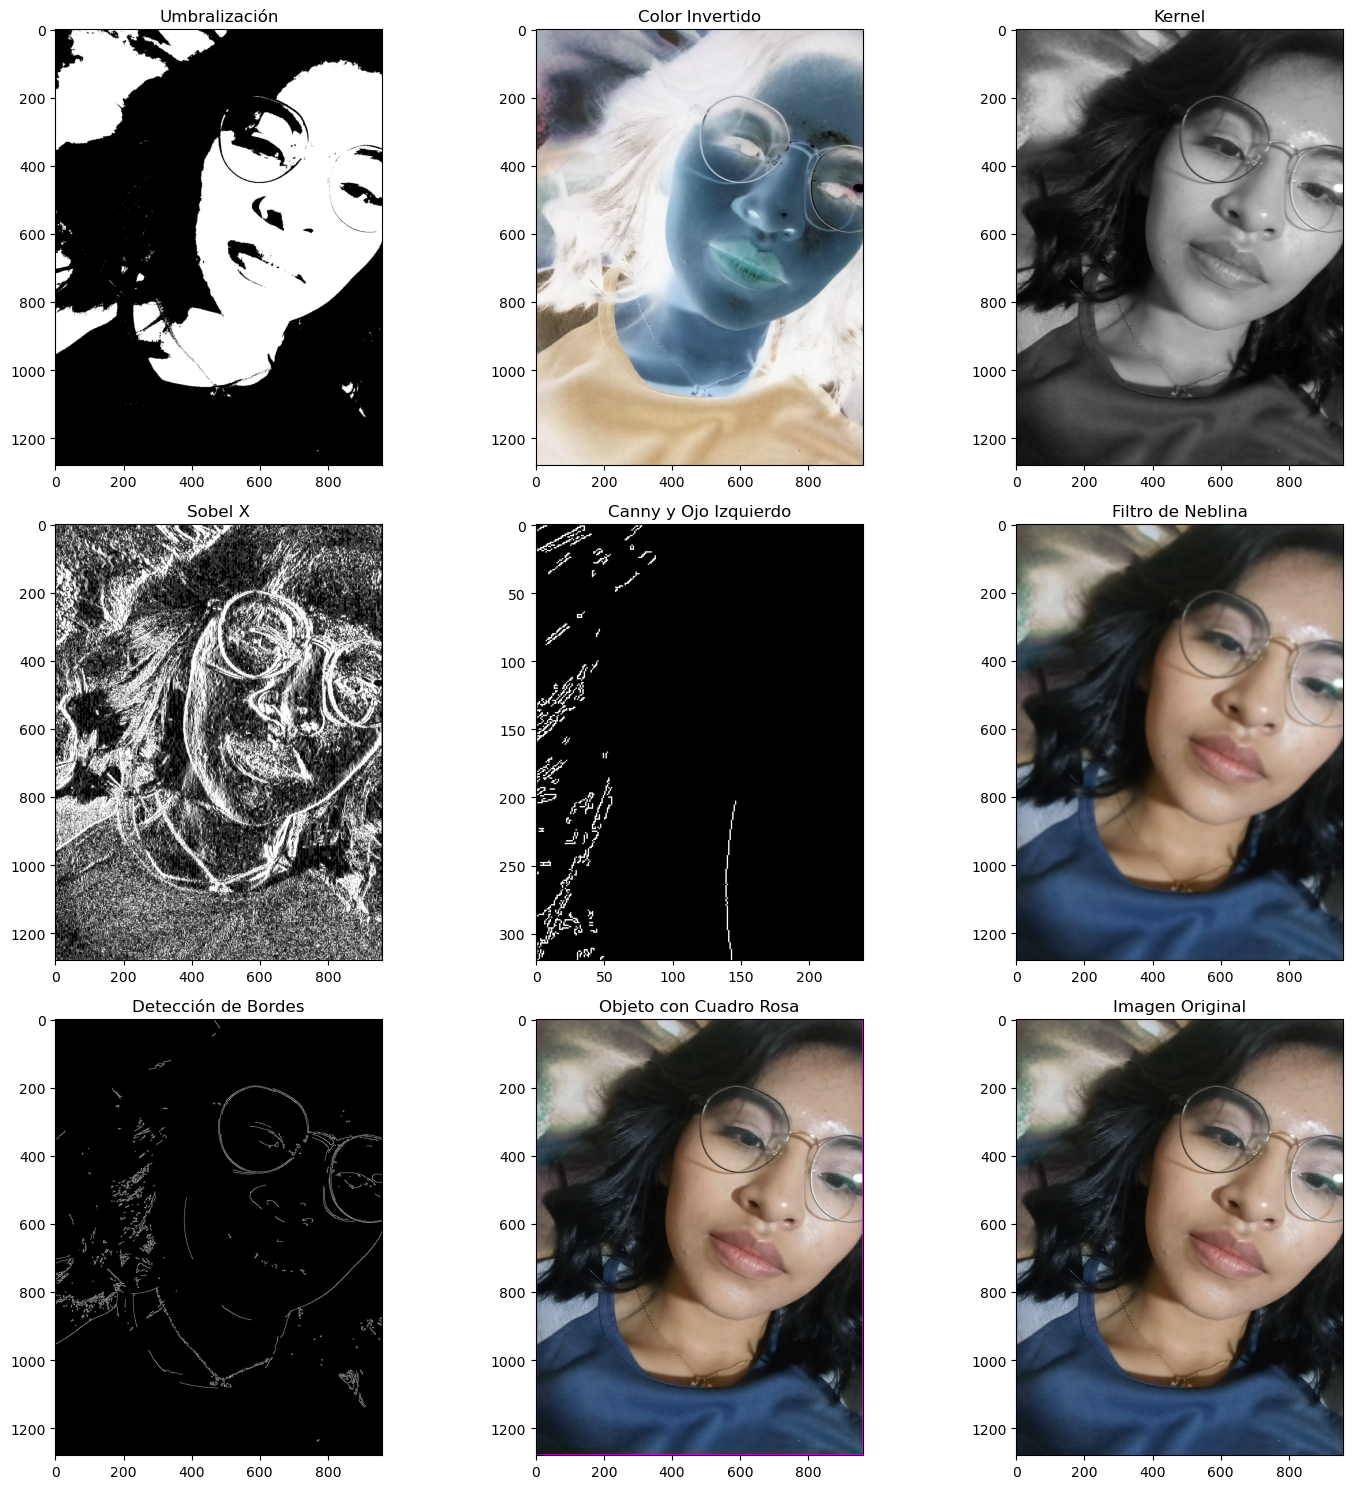

Área del objeto principal: 733493.50
Perímetro: 11787.99
Centroide: (434, 724)


In [5]:
import cv2
import  numpy as np 
import matplotlib.pyplot as plt

imagen = cv2.imread('rostro1.jpeg')
rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
_, umbral = cv2.threshold(gris, 100,255,cv2.THRESH_BINARY)
invertido = 255 - imagen 
kernel_propio = np.array([[1,1,1,1,1]], dtype=np.float32)/5
convolucion_propia = cv2.filter2D(gris, -1, kernel_propio)
sobelx = cv2.Sobel(gris, cv2.CV_64F,1,0, ksize=5)
sobelx = cv2.convertScaleAbs(sobelx)
h,w = gris.shape
ojo_izq = gris[h//4:h//2, w//4:w//2]
ojo_canny = cv2.Canny(ojo_izq,100,200)
neblina = cv2.GaussianBlur(imagen, (15,15),0)
bordes = cv2.Canny(gris, 100, 200)
_, binaria = cv2.threshold(gris,100,255, cv2.THRESH_BINARY_INV)
contornos, _=cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contornos, key=cv2.contourArea)
area = cv2.contourArea(cnt)
perimetro = cv2.arcLength(cnt, True)
M = cv2.moments(cnt)
cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
imagen_copia = imagen.copy()
x, y, w_box, h_box = cv2.boundingRect(cnt)
cv2.rectangle(imagen_copia,(x,y), (x + w_box, y + h_box), (255, 0 , 255),3)

plt.figure(figsize=(15, 15))

plt.subplot(331), plt.imshow(umbral, cmap='gray')
plt.title("Umbralización")
plt.subplot(332), plt.imshow(cv2.cvtColor(invertido, cv2.COLOR_BGR2RGB))
plt.title("Color Invertido")
plt.subplot(333), plt.imshow(convolucion_propia, cmap='gray')
plt.title("Kernel")
plt.subplot(334), plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.subplot(335), plt.imshow(ojo_canny, cmap='gray')
plt.title("Canny y Ojo Izquierdo")
plt.subplot(336), plt.imshow(cv2.cvtColor(neblina, cv2.COLOR_BGR2RGB))
plt.title("Filtro de Neblina")
plt.subplot(337), plt.imshow(bordes, cmap='gray')
plt.title("Detección de Bordes")
plt.subplot(338), plt.imshow(cv2.cvtColor(imagen_copia, cv2.COLOR_BGR2RGB))
plt.title("Objeto con Cuadro Rosa")
plt.subplot(339), plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")

plt.tight_layout()
plt.show()

print(f"Área del objeto principal: {area:.2f}")
print(f"Perímetro: {perimetro:.2f}")
print(f"Centroide: ({cx}, {cy})")

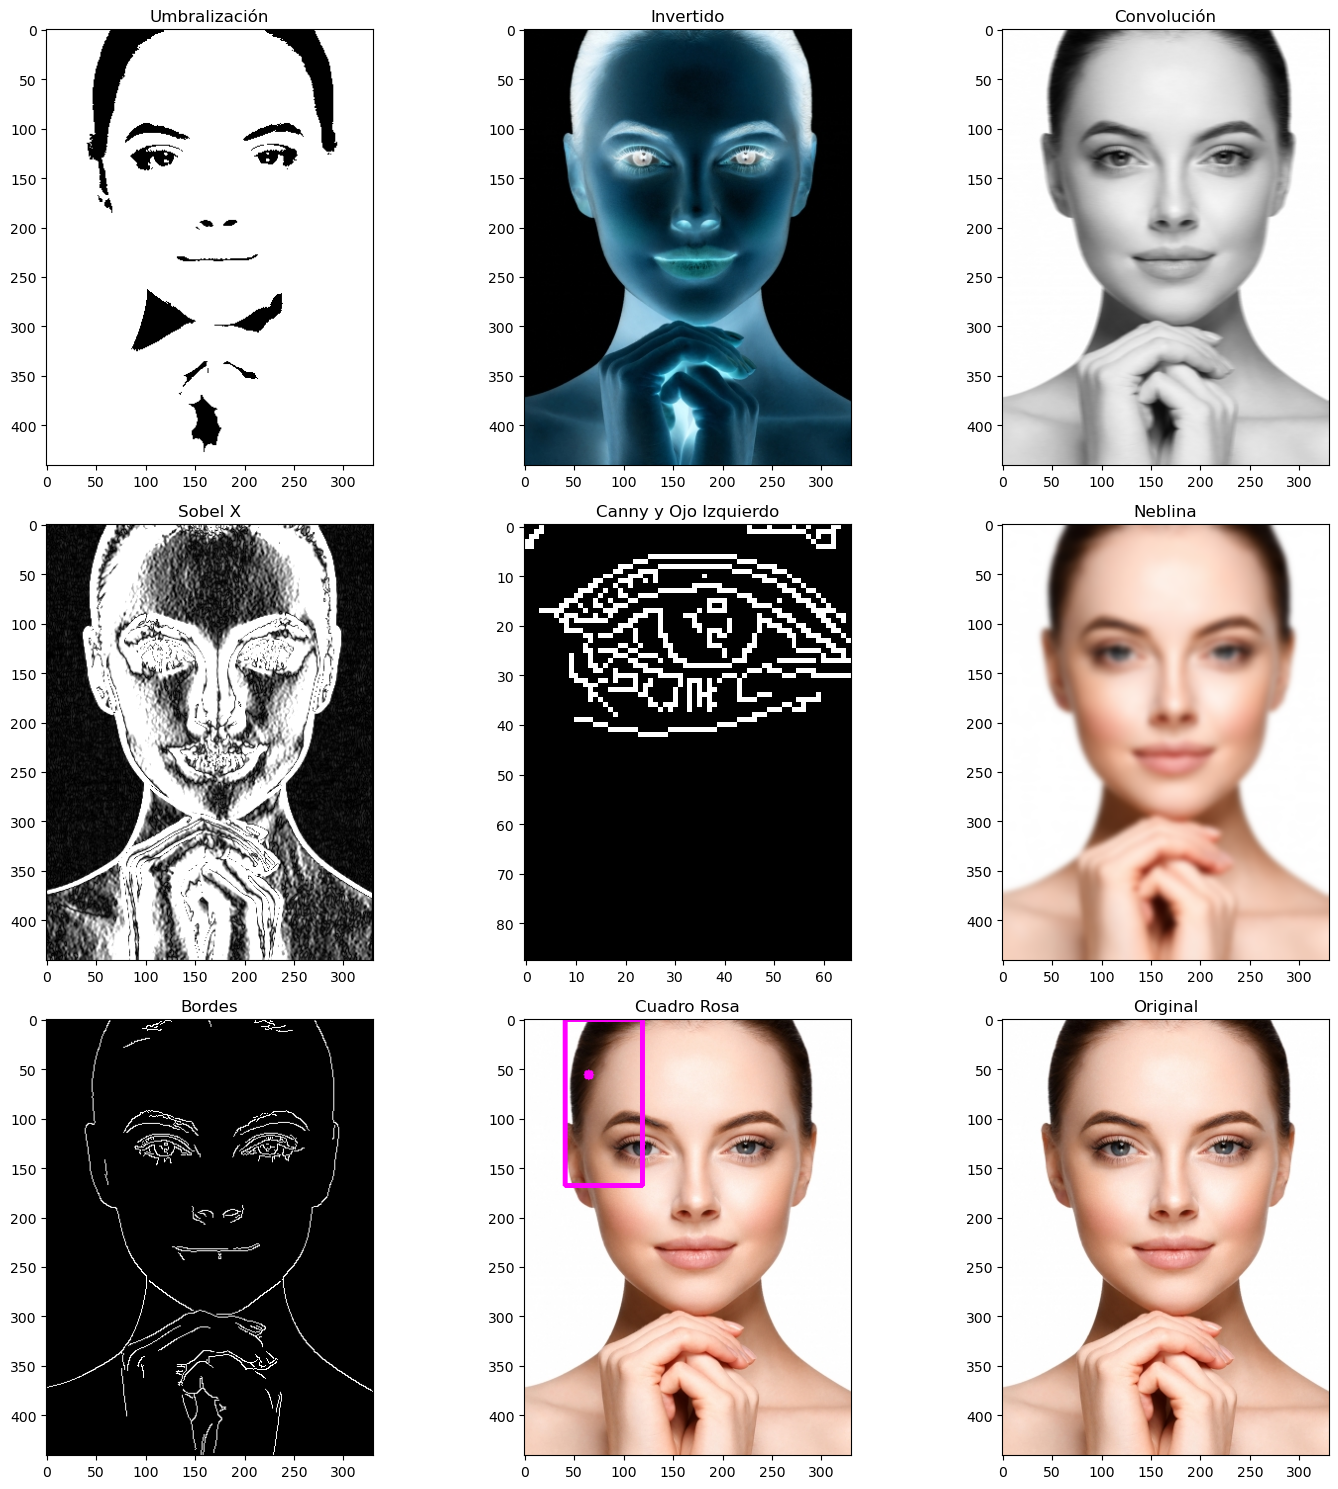

Área detectada: 3426.50
Perímetro: 482.78
Centroide: (65, 56)


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('rostro.jpg')
rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

_, umbral = cv2.threshold(gris, 100, 255, cv2.THRESH_BINARY)

invertido = 255 - imagen

kernel_propio = np.array([[1, 1, 1, 1, 1]], dtype=np.float32) / 5
convolucion_propia = cv2.filter2D(gris, -1, kernel_propio)

sobelx = cv2.Sobel(gris, cv2.CV_64F, 1, 0, ksize=5)
sobelx = cv2.convertScaleAbs(sobelx)

alto, ancho, _ = imagen.shape
x_ini = int(ancho * 0.25)
x_fin = int(ancho * 0.45)
y_ini = int(alto * 0.25)
y_fin = int(alto * 0.45)

ojo_region = imagen[y_ini:y_fin, x_ini:x_fin]  
ojo_gris = cv2.cvtColor(ojo_region, cv2.COLOR_BGR2GRAY)
ojo_canny = cv2.Canny(ojo_gris, 50, 150)


neblina = cv2.GaussianBlur(imagen, (15, 15), 0)

bordes = cv2.Canny(gris, 100, 200)

_, binaria = cv2.threshold(gris, 100, 255, cv2.THRESH_BINARY_INV)
contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cnt = max(contornos, key=cv2.contourArea)
area = cv2.contourArea(cnt)
perimetro = cv2.arcLength(cnt, True)
M = cv2.moments(cnt)
cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])

imagen_copia = imagen.copy()
x, y, w_box, h_box = cv2.boundingRect(cnt)
cv2.rectangle(imagen_copia, (x, y), (x + w_box, y + h_box), (255, 0, 255), 3)  # Rosa
cv2.circle(imagen_copia, (cx, cy), 5, (255, 0, 255), -1)

plt.figure(figsize=(15, 15))

plt.subplot(331), plt.imshow(umbral, cmap='gray')
plt.title("Umbralización")
plt.subplot(332), plt.imshow(cv2.cvtColor(invertido, cv2.COLOR_BGR2RGB))
plt.title("Invertido")
plt.subplot(333), plt.imshow(convolucion_propia, cmap='gray')
plt.title("Convolución")
plt.subplot(334), plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.subplot(335), plt.imshow(ojo_canny, cmap='gray')
plt.title("Canny y Ojo Izquierdo")
plt.subplot(336), plt.imshow(cv2.cvtColor(neblina, cv2.COLOR_BGR2RGB))
plt.title("Neblina")
plt.subplot(337), plt.imshow(bordes, cmap='gray')
plt.title("Bordes")
plt.subplot(338), plt.imshow(cv2.cvtColor(imagen_copia, cv2.COLOR_BGR2RGB))
plt.title("Cuadro Rosa")
plt.subplot(339), plt.imshow(rgb), plt.title("Original")

plt.tight_layout()
plt.show()

print(f"Área detectada: {area:.2f}")
print(f"Perímetro: {perimetro:.2f}")
print(f"Centroide: ({cx}, {cy})")


Ejercicio 3

Objetos detectados: 220
[Obj 1] Área: 0.50, Perímetro: 8.24, Centroide: (686, 933)
[Obj 2] Área: 0.00, Perímetro: 2.00, Centroide: (0, 0)
[Obj 3] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 4] Área: 0.00, Perímetro: 4.00, Centroide: (0, 0)
[Obj 5] Área: 0.00, Perímetro: 2.00, Centroide: (0, 0)
[Obj 6] Área: 0.50, Perímetro: 3.41, Centroide: (722, 922)
[Obj 7] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 8] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 9] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 10] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 11] Área: 0.00, Perímetro: 2.83, Centroide: (0, 0)
[Obj 12] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 13] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 14] Área: 0.00, Perímetro: 2.00, Centroide: (0, 0)
[Obj 15] Área: 0.00, Perímetro: 2.83, Centroide: (0, 0)
[Obj 16] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 17] Área: 0.00, Perímetro: 0.00, Centroide: (0, 0)
[Obj 18] Área: 0.00, Perí

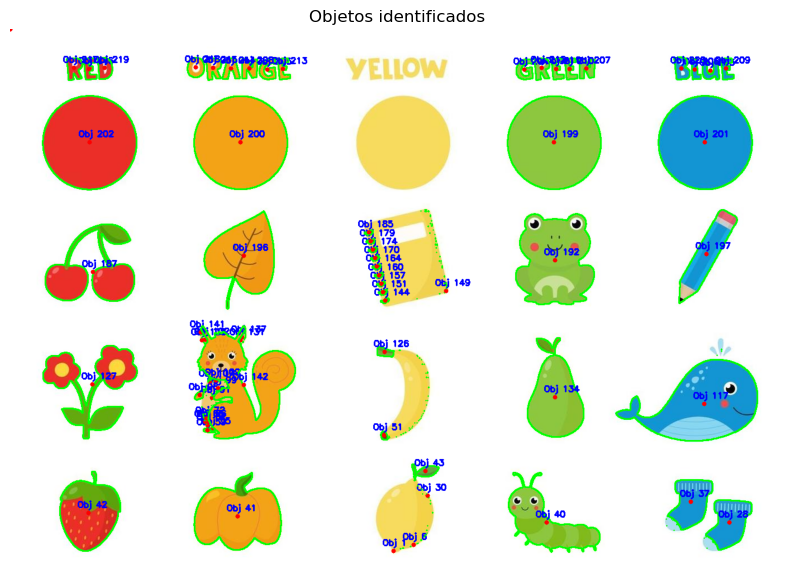

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('colores.jpg')  
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

_, binaria = cv2.threshold(gris, 200, 255, cv2.THRESH_BINARY_INV)

contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

resultado = imagen_rgb.copy()

print(f"Objetos detectados: {len(contornos)}")

for i, cnt in enumerate(contornos):
    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)
    M = cv2.moments(cnt)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    cv2.drawContours(resultado, [cnt], -1, (0, 255, 0), 2)

    cv2.circle(resultado, (cx, cy), 4, (255, 0, 0), -1)

    texto = f"Obj {i+1}"
    cv2.putText(resultado, texto, (cx - 20, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    print(f"[{texto}] Área: {area:.2f}, Perímetro: {perimetro:.2f}, Centroide: ({cx}, {cy})")

plt.figure(figsize=(10, 10))
plt.imshow(resultado)
plt.title("Objetos identificados")
plt.axis('off')
plt.show()


Ejercicio 4

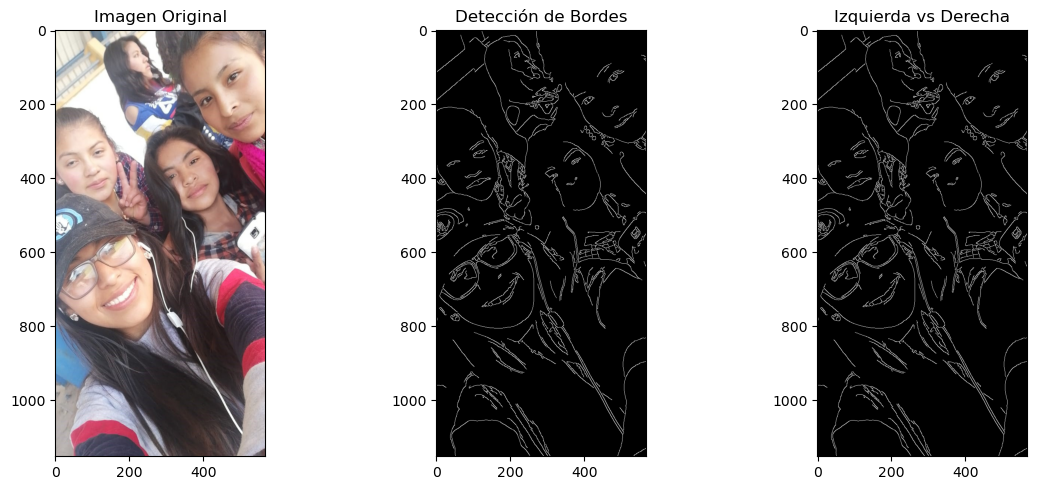

Comparación de la imagen:
Área sucia (izquierda): 14434 píxeles
Área limpia (derecha): 11270 píxeles
Reducción estimada: 3164 píxeles
Porcentaje de mejora: 21.92%
Limpieza visual .


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('T2.jpeg')
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

suavizada = cv2.GaussianBlur(gris, (5, 5), 0)

bordes = cv2.Canny(suavizada, 50, 150)

alto, ancho = bordes.shape
mitad = ancho // 2
izquierda = bordes[:, :mitad]
derecha = bordes[:, mitad:]

area_izquierda = np.sum(izquierda == 255)
area_derecha = np.sum(derecha == 255)

diferencia = area_izquierda - area_derecha
porcentaje = (diferencia / area_izquierda) * 100 if area_izquierda != 0 else 0

plt.figure(figsize=(12, 5))
plt.subplot(131), plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.subplot(132), plt.imshow(bordes, cmap='gray')
plt.title("Detección de Bordes")
plt.subplot(133), plt.imshow(np.hstack((izquierda, derecha)), cmap='gray')
plt.title("Izquierda vs Derecha")
plt.tight_layout()
plt.show()

print("Comparación de la imagen:")
print(f"Área sucia (izquierda): {area_izquierda} píxeles")
print(f"Área limpia (derecha): {area_derecha} píxeles")
print(f"Reducción estimada: {diferencia} píxeles")
print(f"Porcentaje de mejora: {porcentaje:.2f}%")

if porcentaje > 15:
    print("Limpieza visual .")
else:
    print("Las zonas son similares.")
